In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from prophet import Prophet

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# -------------------------
# Config
# -------------------------

# Path to the CSV file
# If you run on Kaggle, a common path is:
#   ../input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv
DATA_PATH = "retail_store_inventory.csv"

# Force a specific series if you want; otherwise the longest series is chosen
CHOSEN_STORE_ID = None  # e.g. "S001"
CHOSEN_PRODUCT_ID = None  # e.g. "P0005"

# Time series split config (in days)
VAL_HORIZON_DAYS = 28
TEST_HORIZON_DAYS = 28

# Future forecast horizon
FORECAST_HORIZON_DAYS = 30

RANDOM_SEED = 42

import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# -------------------------
# Metrics helpers
# -------------------------

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return np.nan
    return float(2.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100)

def evaluate_forecast(y_true, y_pred):
    return {
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "wape": wape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
    }

def metrics_table(results_dict, title=None):
    rows = []
    for (model, split), metrics in results_dict.items():
        row = {"model": model, "split": split}
        row.update(metrics)
        rows.append(row)
    df = pd.DataFrame(rows)
    if title:
        print(title)
    display(df.sort_values(["model", "split"]).reset_index(drop=True))
    return df

print("Imports, config and helpers ready.")


Imports, config and helpers ready.


## 1. Load and clean the dataset

In [2]:

# Try a couple of common paths (local & Kaggle-style)
candidate_paths = [
    Path(DATA_PATH),
    Path("../input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv"),
]

data_path = None
for p in candidate_paths:
    if p.is_file():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find the CSV file. Please check DATA_PATH or the Kaggle input path."
    )

print(f"Using data file: {data_path}")

df = pd.read_csv(data_path)
print("Raw shape:", df.shape)

# Parse dates & sort
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

# Basic cleaning similar to a SARIMAX-style pipeline
numeric_cols = [
    "Units Sold",
    "Inventory Level",
    "Price",
    "Competitor Pricing",
    "Discount",
    "Demand Forecast",
]

for col in numeric_cols:
    if col not in df.columns:
        continue
    if col == "Units Sold":
        df[col] = df[col].fillna(0)
    elif col == "Inventory Level":
        df[col] = df[col].ffill().fillna(0)
    else:
        df[col] = df[col].fillna(df[col].median())

# Clip outliers for Units Sold & Price
for col in ["Units Sold", "Price"]:
    if col in df.columns:
        q1, q99 = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(q1, q99)

if "Holiday/Promotion" in df.columns:
    df["Holiday/Promotion"] = df["Holiday/Promotion"].fillna(0).astype(int)

cat_cols = ["Weather Condition", "Seasonality", "Region", "Category"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).fillna("Unknown")

df = df.drop_duplicates()

print("Cleaned shape:", df.shape)
display(df.head())


Using data file: retail_store_inventory.csv
Raw shape: (73100, 15)
Cleaned shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter


## 2. Select a (Store ID, Product ID) series and build features

In [3]:

# Find longest series if user did not choose
counts = (
    df.groupby(["Store ID", "Product ID"])["Units Sold"]
    .count()
    .sort_values(ascending=False)
)

print("Top 10 series by length:")
display(counts.head(10))

if (CHOSEN_STORE_ID is None) or (CHOSEN_PRODUCT_ID is None):
    store_id, product_id = counts.index[0]
    print("\nAuto-selected longest series:")
else:
    store_id, product_id = CHOSEN_STORE_ID, CHOSEN_PRODUCT_ID
    if (store_id, product_id) not in counts.index:
        raise ValueError(f"Chosen series not found: {store_id}, {product_id}")
    print("\nUsing user-chosen series:")

print("  Store ID   :", store_id)
print("  Product ID :", product_id)

ts = df[(df["Store ID"] == store_id) & (df["Product ID"] == product_id)].copy()
ts = ts.sort_values("Date").set_index("Date")

# Reindex to daily
ts = ts.asfreq("D")
ts["Units Sold"] = ts["Units Sold"].fillna(0)

for col in ["Inventory Level", "Price", "Competitor Pricing", "Discount", "Demand Forecast"]:
    if col in ts.columns:
        if col == "Inventory Level":
            ts[col] = ts[col].ffill().fillna(0)
        else:
            ts[col] = ts[col].ffill().fillna(ts[col].median())

# Calendar features
ts["dow"] = ts.index.dayofweek
ts["month"] = ts.index.month

# Categorical one-hot (for this single series)
cat_cols = [c for c in ["Weather Condition", "Seasonality", "Region", "Category"] if c in ts.columns]
if cat_cols:
    ts_cat = pd.get_dummies(ts[cat_cols].astype("category"), drop_first=True)
else:
    ts_cat = pd.DataFrame(index=ts.index)

numeric_reg_cols = [
    c for c in ["Price", "Discount", "Competitor Pricing", "Demand Forecast", "Inventory Level"]
    if c in ts.columns
]
cal_cols = ["dow", "month"]

pieces = []
if "Holiday/Promotion" in ts.columns:
    pieces.append(ts[["Units Sold", "Holiday/Promotion"]])
else:
    pieces.append(ts[["Units Sold"]])
pieces.append(ts[numeric_reg_cols + cal_cols])
if not ts_cat.empty:
    pieces.append(ts_cat)

model_df = pd.concat(pieces, axis=1)
model_df = model_df.reset_index().rename(columns={"Date": "ds", "Units Sold": "y"})

# Regressors for Prophet
regressor_cols = [c for c in model_df.columns if c not in ["ds", "y", "Holiday/Promotion"]]

# Naive-7 target for baseline only
model_df["y_lag_7"] = model_df["y"].shift(7)

# Drop rows with missing y or regressors (but keep Naive-7 NaNs for now)
model_df = model_df.dropna(subset=["y"] + regressor_cols).reset_index(drop=True)

print("Modeling DataFrame shape:", model_df.shape)
print("Columns:")
print(model_df.columns.tolist())
display(model_df.head())


Top 10 series by length:


Store ID  Product ID
S001      P0001         731
          P0002         731
          P0003         731
          P0004         731
          P0005         731
          P0006         731
          P0007         731
          P0008         731
          P0009         731
          P0010         731
Name: Units Sold, dtype: int64


Auto-selected longest series:
  Store ID   : S001
  Product ID : P0001
Modeling DataFrame shape: (731, 24)
Columns:
['ds', 'y', 'Holiday/Promotion', 'Price', 'Discount', 'Competitor Pricing', 'Demand Forecast', 'Inventory Level', 'dow', 'month', 'Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter', 'Region_North', 'Region_South', 'Region_West', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'y_lag_7']


,ds,y,Holiday/Promotion,Price,Discount,Competitor Pricing,Demand Forecast,Inventory Level,dow,month,...,Seasonality_Summer,Seasonality_Winter,Region_North,Region_South,Region_West,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys,y_lag_7
0,2022-01-01,127,0,33.50,20,29.69,135.47,231,5,1,...,False,False,True,False,False,False,False,True,False,NaN
1,2022-01-02,81,0,27.95,10,30.89,92.94,116,6,1,...,False,False,False,False,True,False,False,True,False,NaN
2,2022-01-03,5,0,62.70,20,58.22,5.36,154,0,1,...,False,True,False,False,True,True,False,False,False,NaN
3,2022-01-04,58,1,77.88,15,75.99,52.87,85,1,1,...,False,True,False,True,False,False,False,True,False,NaN
4,2022-01-05,147,1,28.46,20,29.40,150.27,238,2,1,...,False,True,False,True,False,False,False,True,False,NaN


## 3. Train / validation / test split + Naive-7 baseline

In [4]:

total_len = len(model_df)
min_len_required = VAL_HORIZON_DAYS + TEST_HORIZON_DAYS + 30

if total_len < min_len_required:
    raise ValueError(
        f"Series too short ({total_len} days). "
        f"Need at least {min_len_required} days."
    )

train_end = total_len - (VAL_HORIZON_DAYS + TEST_HORIZON_DAYS)
val_end = total_len - TEST_HORIZON_DAYS

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("Total length:", total_len)
print("Train length:", len(train_df))
print("Val   length:", len(val_df))
print("Test  length:", len(test_df))

baseline_results = {}

for split_name, split_df in zip(["val", "test"], [val_df, test_df]):
    y_true = split_df["y"].values
    y_pred = split_df["y_lag_7"].values

    # Fallback if some NaNs remain
    if np.isnan(y_pred).any():
        fallback = np.nanmean(model_df["y_lag_7"].values)
        y_pred = np.where(np.isnan(y_pred), fallback, y_pred)

    metrics = evaluate_forecast(y_true, y_pred)
    baseline_results[("Naive-7", split_name)] = metrics

baseline_df = metrics_table(baseline_results, title="Naive-7 baseline metrics")


Total length: 731
Train length: 675
Val   length: 28
Test  length: 28
Naive-7 baseline metrics


,model,split,rmse,mape,wape,smape
0,Naive-7,test,132.021373,568.771577,79.467259,77.459936
1,Naive-7,val,170.577381,229.753634,91.439595,95.474584


## 4. Prophet holidays + hyperparameter tuning (validation)

In [5]:

# Holidays from Holiday/Promotion
holidays_df = None
if "Holiday/Promotion" in model_df.columns:
    holidays_df = model_df[model_df["Holiday/Promotion"] == 1][["ds"]].drop_duplicates()
    holidays_df["holiday"] = "promotion"
    holidays_df["lower_window"] = 0
    holidays_df["upper_window"] = 0
    print("Number of holiday/promotion days:", len(holidays_df))
    display(holidays_df.head())
else:
    print("No 'Holiday/Promotion' column found. Proceeding without holidays.")

param_grid = {
    "changepoint_prior_scale": [0.05, 0.1, 0.2],
    "seasonality_mode": ["additive", "multiplicative"],
    "holidays_prior_scale": [1.0, 5.0, 10.0],
}

all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

tuning_rows = []

print("Starting Prophet hyperparameter search...\n")
for i, params in enumerate(all_params, start=1):
    print(f"Config {i}/{len(all_params)}: {params}")

    m = Prophet(
        growth="linear",
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_mode=params["seasonality_mode"],
        holidays_prior_scale=params["holidays_prior_scale"],
        holidays=holidays_df,
    )

    for reg in regressor_cols:
        m.add_regressor(reg)

    m.fit(train_df[["ds", "y"] + regressor_cols])

    val_future = val_df[["ds"] + regressor_cols].copy()
    val_forecast = m.predict(val_future)

    y_val_true = val_df["y"].values
    y_val_pred = val_forecast["yhat"].values

    metrics = evaluate_forecast(y_val_true, y_val_pred)
    row = {
        "changepoint_prior_scale": params["changepoint_prior_scale"],
        "seasonality_mode": params["seasonality_mode"],
        "holidays_prior_scale": params["holidays_prior_scale"],
    }
    row.update(metrics)
    tuning_rows.append(row)

    print(
        f"  -> Val RMSE={metrics['rmse']:.3f}, "
        f"MAPE={metrics['mape']:.2f}%, "
        f"WAPE={metrics['wape']:.2f}%, "
        f"sMAPE={metrics['smape']:.2f}%"
    )

tuning_df = pd.DataFrame(tuning_rows).sort_values("rmse").reset_index(drop=True)
print("\nTop Prophet configs (by RMSE):")
display(tuning_df.head(10))

best_row = tuning_df.iloc[0]
best_params = {
    "changepoint_prior_scale": float(best_row["changepoint_prior_scale"]),
    "seasonality_mode": best_row["seasonality_mode"],
    "holidays_prior_scale": float(best_row["holidays_prior_scale"]),
}
best_val_metrics = {
    "rmse": float(best_row["rmse"]),
    "mape": float(best_row["mape"]),
    "wape": float(best_row["wape"]),
    "smape": float(best_row["smape"]),
}

print("\nBest Prophet params:")
print(best_params)
print("\nBest validation metrics:")
print(best_val_metrics)


Number of holiday/promotion days: 349


,ds,holiday,lower_window,upper_window
3,2022-01-04,promotion,0,0
4,2022-01-05,promotion,0,0
6,2022-01-07,promotion,0,0
7,2022-01-08,promotion,0,0
8,2022-01-09,promotion,0,0


Starting Prophet hyperparameter search...

Config 1/18: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive', 'holidays_prior_scale': 1.0}


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


  -> Val RMSE=8.604, MAPE=8.02%, WAPE=4.88%, sMAPE=8.30%
Config 2/18: {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive', 'holidays_prior_scale': 5.0}


...

  -> Val RMSE=9.002, MAPE=8.37%, WAPE=5.27%, sMAPE=8.20%
Config 17/18: {'changepoint_prior_scale': 0.2, 'seasonality_mode': 'multiplicative', 'holidays_prior_scale': 5.0}


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


  -> Val RMSE=8.982, MAPE=8.35%, WAPE=5.25%, sMAPE=8.20%
Config 18/18: {'changepoint_prior_scale': 0.2, 'seasonality_mode': 'multiplicative', 'holidays_prior_scale': 10.0}
  -> Val RMSE=8.971, MAPE=8.35%, WAPE=5.24%, sMAPE=8.19%

Top Prophet configs (by RMSE):


,changepoint_prior_scale,seasonality_mode,holidays_prior_scale,rmse,mape,wape,smape
0,0.20,additive,1.0,8.527327,7.968421,4.780459,8.413679
1,0.20,additive,10.0,8.527926,7.974070,4.781389,8.420577
2,0.20,additive,5.0,8.528496,7.974520,4.782499,8.419103
3,0.10,additive,5.0,8.552023,7.982613,4.820475,8.352964
4,0.10,additive,10.0,8.554537,7.982611,4.821150,8.354445
5,0.10,additive,1.0,8.554604,7.980397,4.817915,8.361117
6,0.05,additive,5.0,8.595493,8.013107,4.870727,8.300048
7,0.05,additive,10.0,8.597327,8.012154,4.871387,8.299650
8,0.05,additive,1.0,8.603787,8.020431,4.878980,8.295797
9,0.05,multiplicative,5.0,8.717232,8.068226,4.987127,7.980529



Best Prophet params:
{'changepoint_prior_scale': 0.2, 'seasonality_mode': 'additive', 'holidays_prior_scale': 1.0}

Best validation metrics:
{'rmse': 8.527327408955099, 'mape': 7.968420559650356, 'wape': 4.780458701028762, 'smape': 8.413679116571737}


## 5. Final Prophet model (train + val), test metrics & fit visualization

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet test metrics:
{'rmse': 9.779439163024003, 'mape': 24.078265374470845, 'wape': 5.873131916306117, 'smape': 17.582941440112158}
Model comparison (Naive-7 vs Prophet)


,model,split,rmse,mape,wape,smape
0,Naive-7,test,132.021373,568.771577,79.467259,77.459936
1,Naive-7,val,170.577381,229.753634,91.439595,95.474584
2,Prophet,test,9.779439,24.078265,5.873132,17.582941
3,Prophet,val,8.527327,7.968421,4.780459,8.413679


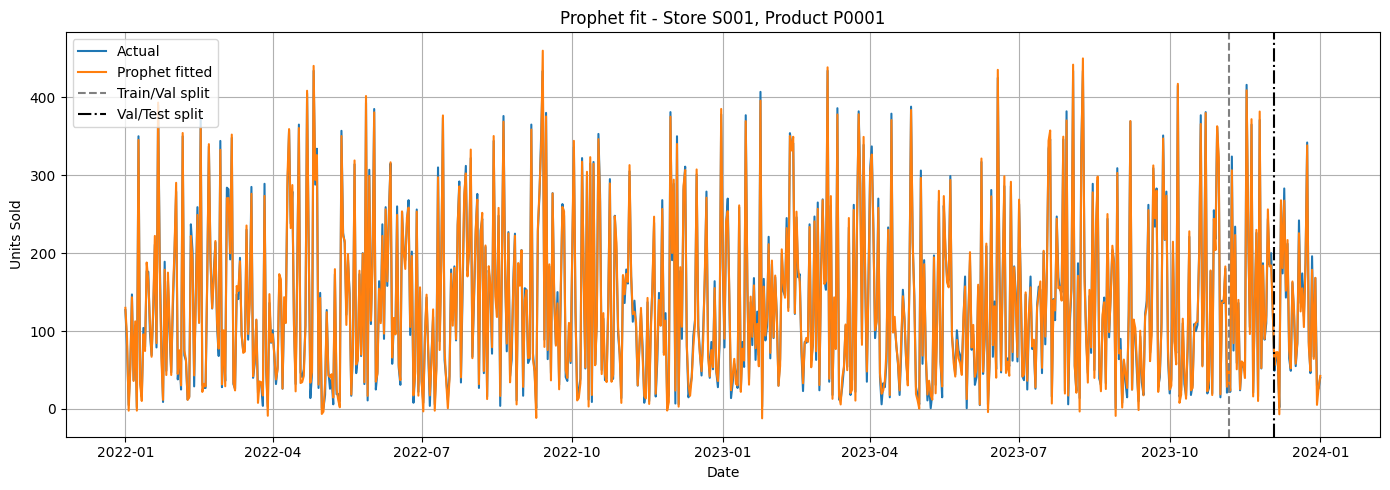

In [6]:

# Train + validation for final model
train_val_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

m_final = Prophet(
    growth="linear",
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    seasonality_mode=best_params["seasonality_mode"],
    holidays_prior_scale=best_params["holidays_prior_scale"],
    holidays=holidays_df,
)

for reg in regressor_cols:
    m_final.add_regressor(reg)

m_final.fit(train_val_df[["ds", "y"] + regressor_cols])

# Predict on test
test_future = test_df[["ds"] + regressor_cols].copy()
test_forecast = m_final.predict(test_future)

y_test_true = test_df["y"].values
y_test_pred = test_forecast["yhat"].values

prophet_test_metrics = evaluate_forecast(y_test_true, y_test_pred)
print("Prophet test metrics:")
print(prophet_test_metrics)

# Summary table (Naive-7 vs Prophet)
all_results = {}
all_results[("Naive-7", "val")] = baseline_results[("Naive-7", "val")]
all_results[("Naive-7", "test")] = baseline_results[("Naive-7", "test")]
all_results[("Prophet", "val")] = best_val_metrics
all_results[("Prophet", "test")] = prophet_test_metrics

summary_df = metrics_table(all_results, title="Model comparison (Naive-7 vs Prophet)")

# In-sample fitted values for whole history
full_future = model_df[["ds"] + regressor_cols].copy()
full_forecast = m_final.predict(full_future)

hist_pred = model_df[["ds", "y"]].merge(
    full_forecast[["ds", "yhat"]],
    on="ds",
    how="left",
)

plt.figure(figsize=(14, 5))
plt.plot(hist_pred["ds"], hist_pred["y"], label="Actual")
plt.plot(hist_pred["ds"], hist_pred["yhat"], label="Prophet fitted")
plt.axvline(train_df["ds"].iloc[-1], color="grey", linestyle="--", label="Train/Val split")
plt.axvline(val_df["ds"].iloc[-1], color="black", linestyle="-.", label="Val/Test split")
plt.title(f"Prophet fit - Store {store_id}, Product {product_id}")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Forecast into the future and view Prophet components

Future forecast head:


,ds,yhat,yhat_lower,yhat_upper
0,2024-01-02,44.649751,33.550282,54.406467
1,2024-01-03,42.195117,31.828654,52.199498
2,2024-01-04,42.984167,33.005854,53.427926
3,2024-01-05,43.347354,32.265189,53.437836
4,2024-01-06,42.990286,32.432638,54.181074


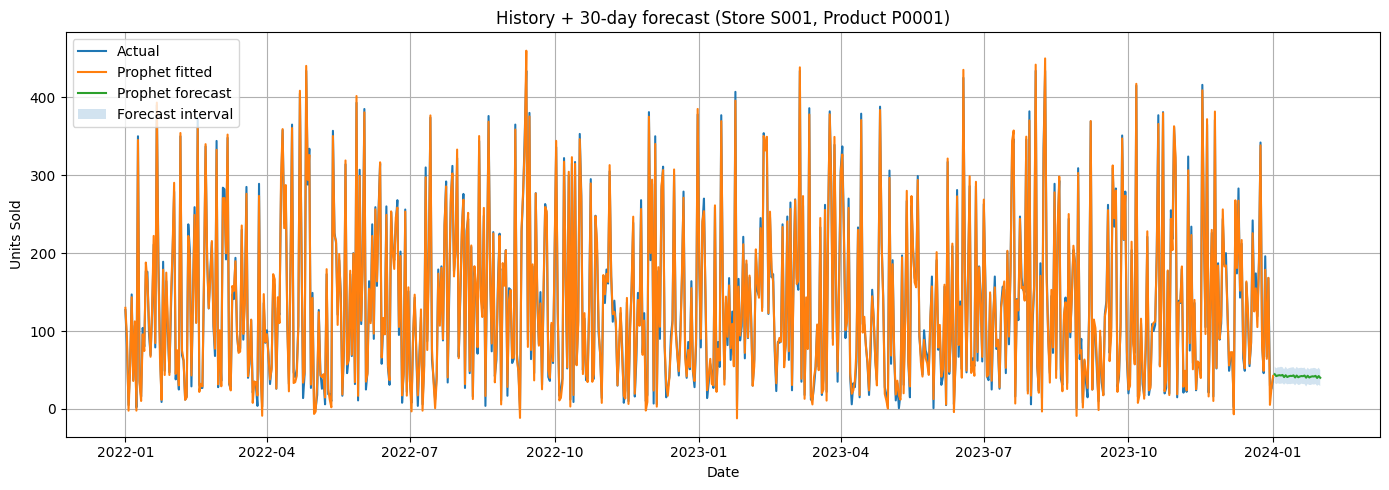

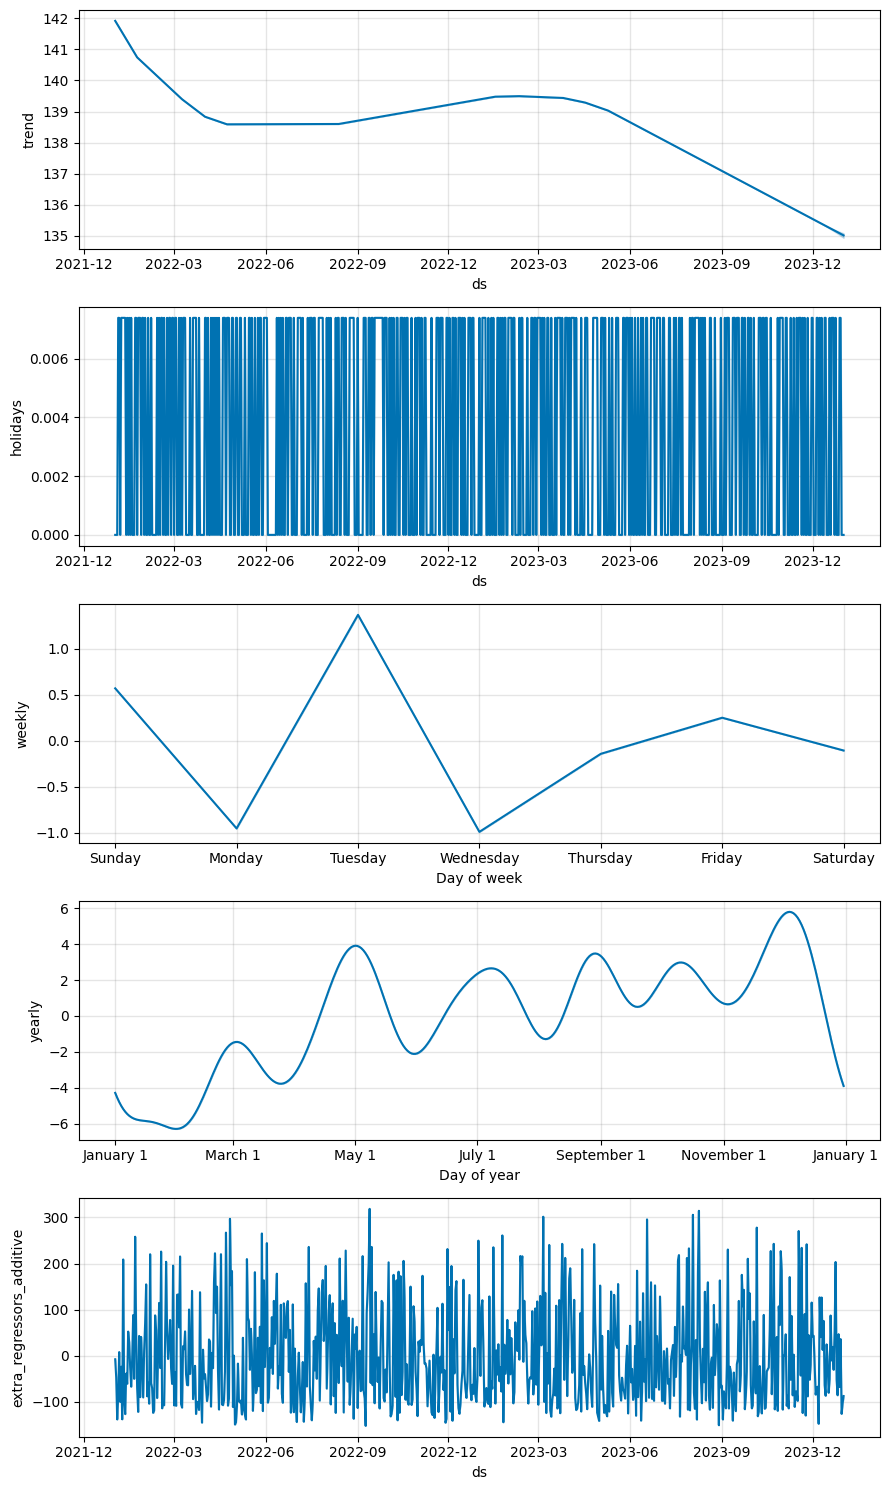

In [7]:

last_date = model_df["ds"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1),
                             periods=FORECAST_HORIZON_DAYS, freq="D")

last_row = model_df.iloc[-1]

future_reg = pd.DataFrame({"ds": future_dates})
for reg in regressor_cols:
    if reg == "dow":
        future_reg["dow"] = future_reg["ds"].dt.dayofweek
    elif reg == "month":
        future_reg["month"] = future_reg["ds"].dt.month
    else:
        future_reg[reg] = last_row[reg]

full_plus_future = pd.concat(
    [model_df[["ds"] + regressor_cols], future_reg],
    axis=0,
    ignore_index=True,
)

full_plus_forecast = m_final.predict(full_plus_future)
future_forecast = full_plus_forecast[full_plus_future["ds"].isin(future_dates)][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].reset_index(drop=True)

print("Future forecast head:")
display(future_forecast.head())

plt.figure(figsize=(14, 5))
plt.plot(hist_pred["ds"], hist_pred["y"], label="Actual")
plt.plot(hist_pred["ds"], hist_pred["yhat"], label="Prophet fitted")
plt.plot(future_forecast["ds"], future_forecast["yhat"], label="Prophet forecast")
plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    alpha=0.2,
    label="Forecast interval",
)
plt.title(
    f"History + {FORECAST_HORIZON_DAYS}-day forecast "
    f"(Store {store_id}, Product {product_id})"
)
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

# Prophet components on full history
_ = m_final.plot_components(full_forecast)
plt.tight_layout()
plt.show()


## 7. Export Prophet reports to CSV (for comparison & presentation)

In [8]:

from pathlib import Path

output_dir = Path("exports_prophet")
output_dir.mkdir(exist_ok=True)
print(f"Saving reports to: {output_dir.resolve()}")

# 1) Metrics table (Naive-7 vs Prophet)
metrics_path = output_dir / "metrics_naive7_vs_prophet.csv"
summary_df.to_csv(metrics_path, index=False)
print("Saved metrics table ->", metrics_path.name)

# 2) Test predictions (actual + Naive-7 + Prophet + interval)
test_export = test_df[["ds", "y"]].copy()
test_export.rename(columns={"y": "y_actual"}, inplace=True)
test_export["y_naive7"] = test_df["y_lag_7"].values
test_export["y_prophet"] = y_test_pred
test_export["yhat_lower"] = test_forecast["yhat_lower"].values
test_export["yhat_upper"] = test_forecast["yhat_upper"].values

test_path = output_dir / "prophet_test_predictions.csv"
test_export.to_csv(test_path, index=False)
print("Saved test predictions ->", test_path.name)

# 3) Full history + fitted
history_export = hist_pred.copy()
history_export.rename(columns={"y": "y_actual", "yhat": "y_prophet_fitted"}, inplace=True)
history_path = output_dir / "prophet_full_history_fitted.csv"
history_export.to_csv(history_path, index=False)
print("Saved full history + fitted ->", history_path.name)

# 4) Future 30-day forecast
future_path = output_dir / "prophet_30day_forecast.csv"
future_forecast.to_csv(future_path, index=False)
print("Saved 30-day forecast ->", future_path.name)

print("\nAll Prophet reports exported successfully.")


Saving reports to: /content/exports_prophet
Saved metrics table -> metrics_naive7_vs_prophet.csv
Saved test predictions -> prophet_test_predictions.csv
Saved full history + fitted -> prophet_full_history_fitted.csv
Saved 30-day forecast -> prophet_30day_forecast.csv

All Prophet reports exported successfully.
